In [6]:
# Import library
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Load dataset
df = pd.read_csv("ObesityDataSet.csv")

In [3]:
# Tampilkan 5 baris pertama
print(df.head())

  Age  Gender Height Weight        CALC FAVC FCVC NCP  SCC SMOKE CH2O  \
0  21  Female   1.62     64          no   no    2   3   no    no    2   
1  21  Female   1.52     56   Sometimes   no    3   3  yes   yes    3   
2  23    Male    1.8     77  Frequently   no    2   3   no    no    2   
3  27    Male    1.8     87  Frequently   no    3   3   no    no    2   
4  22    Male   1.78   89.8   Sometimes   no    2   1   no    no    2   

  family_history_with_overweight FAF TUE       CAEC                 MTRANS  \
0                            yes   0   1  Sometimes  Public_Transportation   
1                            yes   3   0  Sometimes  Public_Transportation   
2                            yes   2   1  Sometimes  Public_Transportation   
3                             no   2   0  Sometimes                Walking   
4                             no   0   0  Sometimes  Public_Transportation   

            NObeyesdad  
0        Normal_Weight  
1        Normal_Weight  
2        Normal_W

In [4]:
# Info dataset
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Age                             2097 non-null   object
 1   Gender                          2102 non-null   object
 2   Height                          2099 non-null   object
 3   Weight                          2100 non-null   object
 4   CALC                            2106 non-null   object
 5   FAVC                            2100 non-null   object
 6   FCVC                            2103 non-null   object
 7   NCP                             2099 non-null   object
 8   SCC                             2101 non-null   object
 9   SMOKE                           2106 non-null   object
 10  CH2O                            2105 non-null   object
 11  family_history_with_overweight  2098 non-null   object
 12  FAF                             2103 non-null   

In [5]:
# Statistik deskriptif untuk data numerik
print(df.describe())

         Age Gender Height Weight       CALC  FAVC  FCVC   NCP   SCC SMOKE  \
count   2097   2102   2099   2100       2106  2100  2103  2099  2101  2106   
unique  1394      3   1562   1518          5     3   808   637     3     3   
top       18   Male    1.7     80  Sometimes   yes     3     3    no    no   
freq     124   1056     58     58       1386  1844   647  1183  1997  2054   

        CH2O family_history_with_overweight   FAF   TUE       CAEC  \
count   2105                           2098  2103  2102       2100   
unique  1263                              3  1186  1130          5   
top        2                            yes     0     0  Sometimes   
freq     441                           1705   404   552       1747   

                       MTRANS      NObeyesdad  
count                    2105            2111  
unique                      6               7  
top     Public_Transportation  Obesity_Type_I  
freq                     1572             351  


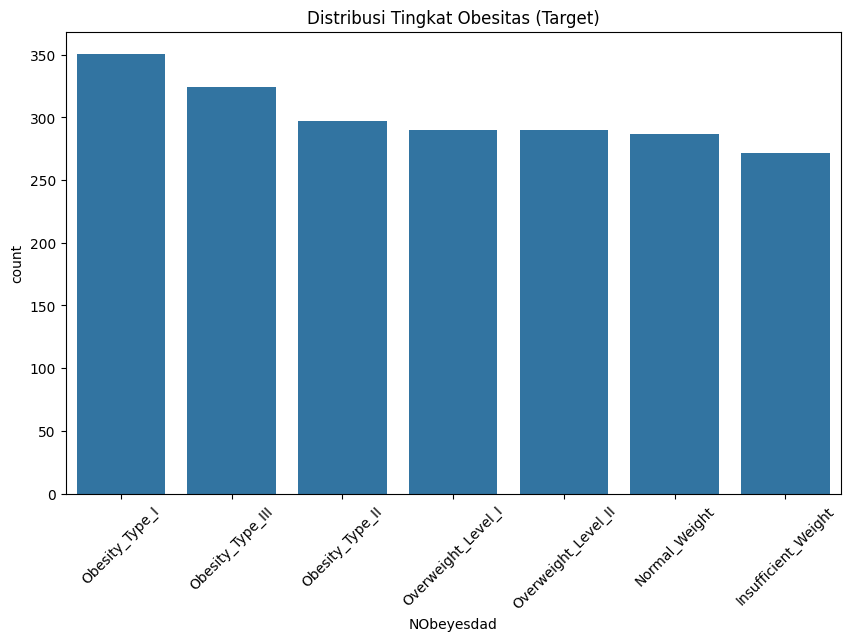

In [7]:
# Distribusi variabel target
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='NObeyesdad', order=df['NObeyesdad'].value_counts().index)
plt.xticks(rotation=45)
plt.title('Distribusi Tingkat Obesitas (Target)')
plt.show()

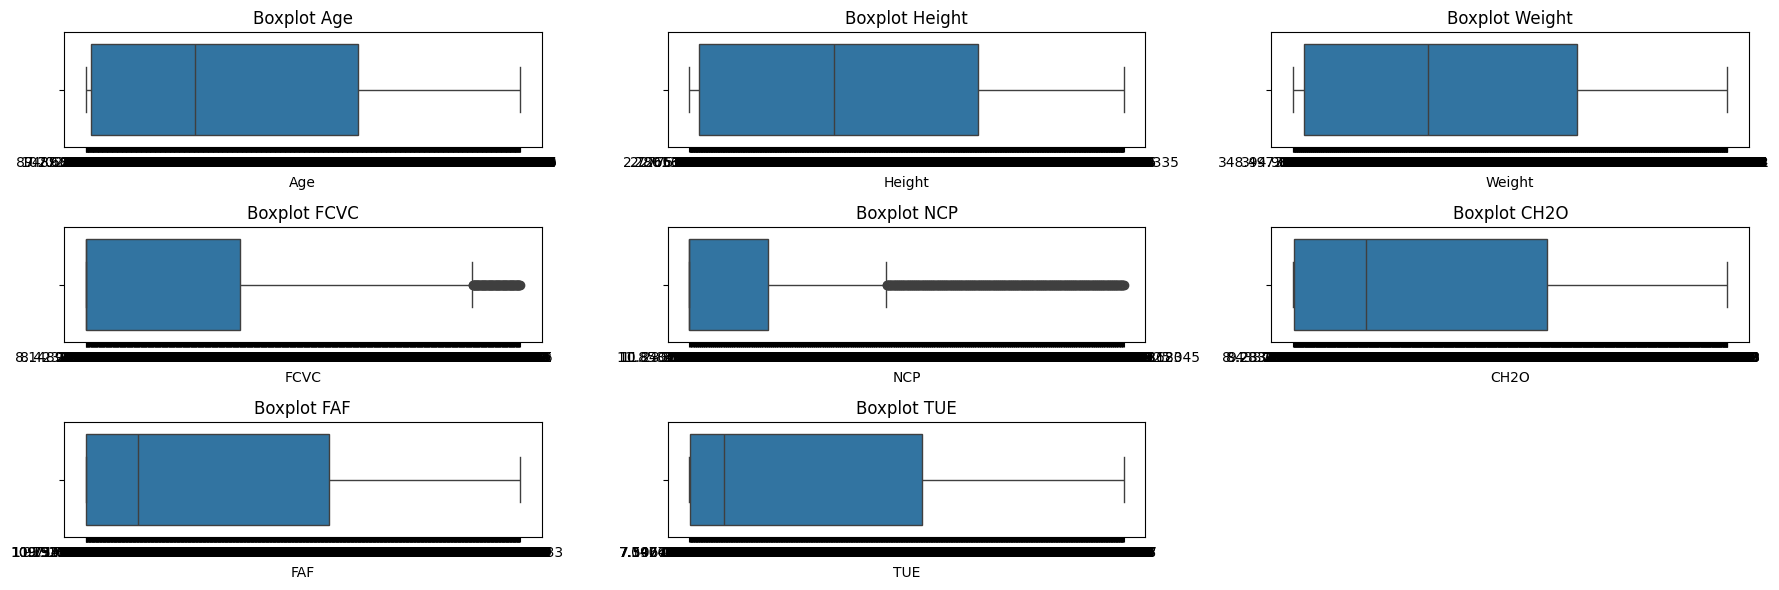

In [18]:
# Deteksi outlier
num_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

# Menentukan jumlah kolom 3 dan jumlah baris secara otomatis
ncols = 3
nrows = (len(num_cols) + ncols - 1) // ncols  # Menentukan jumlah baris

plt.figure(figsize=(18, 6))  # Ukuran gambar

for i, col in enumerate(num_cols):
    plt.subplot(nrows, ncols, i+1)  # Membuat subplot berdasarkan jumlah baris dan kolom
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot {col}')

plt.tight_layout()
plt.show()

In [10]:
# Missing values
print(df.isnull().sum())

Age                               14
Gender                             9
Height                            12
Weight                            11
CALC                               5
FAVC                              11
FCVC                               8
NCP                               12
SCC                               10
SMOKE                              5
CH2O                               6
family_history_with_overweight    13
FAF                                8
TUE                                9
CAEC                              11
MTRANS                             6
NObeyesdad                         0
dtype: int64


In [11]:
# Data duplikat
print(f"Jumlah data duplikat: {df.duplicated().sum()}")

Jumlah data duplikat: 18


In [12]:
# Nilai unik
for col in df.columns:
    print(f'{col}: {df[col].nunique()} nilai unik')

Age: 1394 nilai unik
Gender: 3 nilai unik
Height: 1562 nilai unik
Weight: 1518 nilai unik
CALC: 5 nilai unik
FAVC: 3 nilai unik
FCVC: 808 nilai unik
NCP: 637 nilai unik
SCC: 3 nilai unik
SMOKE: 3 nilai unik
CH2O: 1263 nilai unik
family_history_with_overweight: 3 nilai unik
FAF: 1186 nilai unik
TUE: 1130 nilai unik
CAEC: 5 nilai unik
MTRANS: 6 nilai unik
NObeyesdad: 7 nilai unik


In [13]:
# Keseimbangan target kelas
print(df['NObeyesdad'].value_counts(normalize=True) * 100)

NObeyesdad
Obesity_Type_I         16.627191
Obesity_Type_III       15.348176
Obesity_Type_II        14.069162
Overweight_Level_I     13.737565
Overweight_Level_II    13.737565
Normal_Weight          13.595452
Insufficient_Weight    12.884889
Name: proportion, dtype: float64


Kesimpulan:
- Dataset terdiri dari 2.111 entri dan 17 fitur, sebagian besar bertipe object.
- Terdapat missing values di hampir semua kolom dan 18 data duplikat.
- Fitur numerik seperti Age, Height, dan Weight memiliki variasi yang tinggi.
- Mayoritas responden: menggunakan transportasi umum, tidak merokok, memiliki riwayat obesitas dalam keluarga.
- Distribusi kelas NObeyesdad cukup seimbang untuk klasifikasi multi-kelas.
- Terdapat outlier di beberapa fitur, seperti FCVC (Frekuensi konsumsi sayur) dan NCP (Jumlah konsumsi makanan utama per hari)